In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("house dataset.csv", sep=";")
df.columns = df.columns.str.strip()

print("Kolom dataset:")
print(df.columns)
df.head()

Kolom dataset:
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=["Location", "Condition", "Garage"],
    drop_first=True
)

In [ ]:
X = df_encoded.drop(columns=["Id", "Price"])
y = df_encoded["Price"]

In [ ]:
# 70% Training, 30% sementara
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# 15% Validation, 15% Testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("\nJumlah data:")
print("Training   :", X_train.shape[0])
print("Validation :", X_val.shape[0])
print("Testing    :", X_test.shape[0])


Jumlah data:
Training   : 1400
Validation : 300
Testing    : 300


In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Decision Tree
dt = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=5,
    random_state=42
)
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_split=5, random_state=42)

In [ ]:
depth_candidates = [3, 5, 7]
rmse_scores = []

for depth in depth_candidates:
    dt_temp = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )
    dt_temp.fit(X_train, y_train)
    y_val_pred = dt_temp.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    rmse_scores.append(rmse)

best_depth = depth_candidates[np.argmin(rmse_scores)]

print("\nBest max_depth berdasarkan validasi:", best_depth)


Best max_depth berdasarkan validasi: 3


In [ ]:
dt = DecisionTreeRegressor(
    max_depth=best_depth,
    random_state=42
)
dt.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [ ]:
def evaluate(model, X, y):
    y_pred = model.predict(X)
    return {
        "MAE": mean_absolute_error(y, y_pred),
        "MSE": mean_squared_error(y, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
        "R2": r2_score(y, y_pred)
    }

In [ ]:
hasil_validasi = pd.DataFrame([
    {"Model": "Linear Regression", **evaluate(lr, X_val, y_val)},
    {"Model": "Decision Tree", **evaluate(dt, X_val, y_val)}
])

print("\nHasil Validasi:")
print(hasil_validasi)


Hasil Validasi:
               Model            MAE           MSE           RMSE        R2
0  Linear Regression  246898.796115  7.926805e+10  281545.817279 -0.018739
1      Decision Tree  243529.600029  7.772227e+10  278787.144397  0.001127


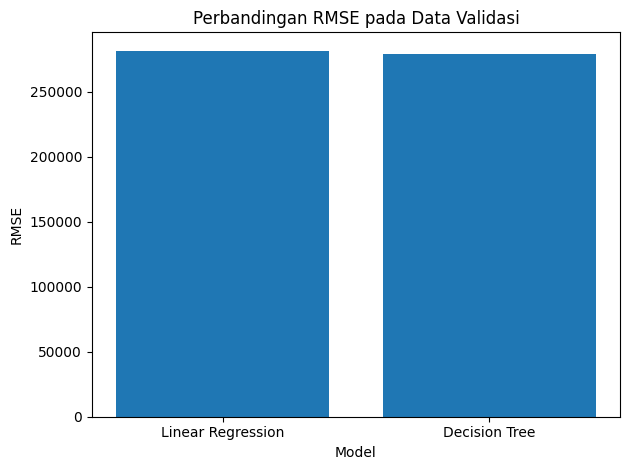

In [ ]:
plt.figure()
plt.bar(hasil_validasi["Model"], hasil_validasi["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Perbandingan RMSE pada Data Validasi")
plt.tight_layout()
plt.savefig("rmse_validasi.png", dpi=300)
plt.show()

In [ ]:
hasil_testing = pd.DataFrame([
    {"Model": "Linear Regression", **evaluate(lr, X_test, y_test)},
    {"Model": "Decision Tree", **evaluate(dt, X_test, y_test)}
])

print("\nHasil Testing:")
print(hasil_testing)


Hasil Testing:
               Model            MAE           MSE           RMSE        R2
0  Linear Regression  244951.939212  7.960869e+10  282150.118249 -0.004995
1      Decision Tree  247906.743296  8.194878e+10  286266.978414 -0.034537


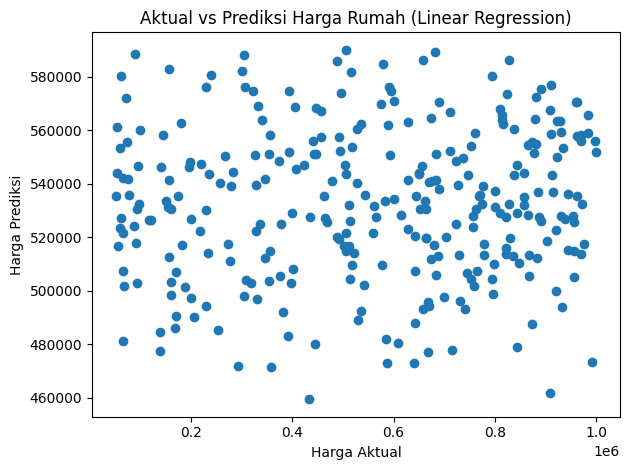

In [ ]:
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")
plt.title("Aktual vs Prediksi Harga Rumah (Linear Regression)")
plt.tight_layout()
plt.savefig("aktual_vs_prediksi_lr.png", dpi=300)
plt.show()

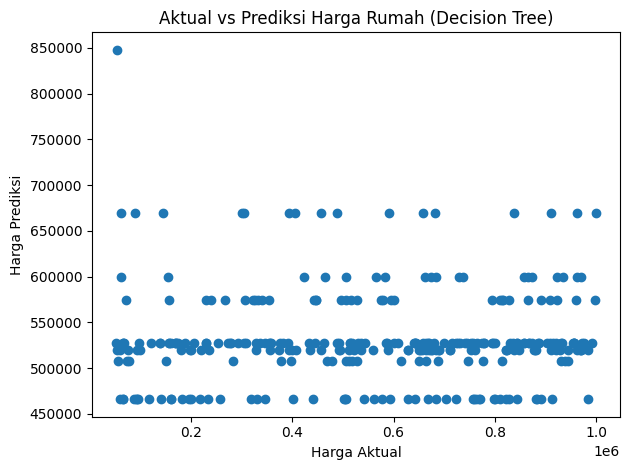

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred_dt)
plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")
plt.title("Aktual vs Prediksi Harga Rumah (Decision Tree)")
plt.tight_layout()
plt.savefig("aktual_vs_prediksi_dt.png", dpi=300)
plt.show()